In [ ]:
# --- repo bootstrap (auto-added) ---
# Run paths relative to the repo root and make src/ importable.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
_SRC = os.path.abspath("src")
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)


# Analysis of the results from MMLU tests

MMLU dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

**Both control and normative categories included**

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)


**Only normative categories included**

- [Zero-shot results analysis](#Zero-shot-Normative)

- [Few-shot results analysis](#Few-shot-Normative)


**Only control categories included**

- [Zero-shot results analysis](#Zero-shot-Control)

- [Few-shot results analysis](#Few-shot-Control)


In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import pandas as pd
from typing import List
from data_loader import fetch_categories_mmlu, load_mmlu_dataset

## Loading the MMLU dataset
normative_category = [
    "moral_disputes",
    "philosophy",
    "world_religions",
    "us_foreign_policy",
    "sociology",
    "professional_psychology",
    "professional_law",
    "moral_scenarios",
    "human_sexuality",
    "international_law",
]

control_category = ["college_mathematics",
    "college_physics",
    "formal_logic",
    "logical_fallacies",
    "college_computer_science",
]

dataset_subjects = normative_category + control_category

mmlu_full_df = fetch_categories_mmlu(dataset_subjects)

samples_per_subject = 50
samples_examples_per_subject = 5

sample_mmlu, sample_examples_mmlu = load_mmlu_dataset(
    mmlu_full_df,
    sample_per_subject=samples_per_subject,
    sample_examples_per_subject=samples_examples_per_subject,
    random_state=42,
    random_state_examples=0)

print(f"Sample MMLU shape: {sample_mmlu.shape}")
print(f"Sample Examples MMLU shape: {sample_examples_mmlu.shape}")
print("Subjects in sample_mmlu:", sample_mmlu["subject"].nunique())
print("Subjects in sample_examples_mmlu:", sample_examples_mmlu["subject"].nunique())


Sample MMLU shape: (750, 7)
Sample Examples MMLU shape: (75, 7)
Subjects in sample_mmlu: 15
Subjects in sample_examples_mmlu: 15


# Zero-shot
### Analysis results zero-shot - MMLU results

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control = merged_df.loc[merged_df["category"] == "control"]
merged_df_normative = merged_df.loc[merged_df["category"] == "normative"]

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df, case=mmlu_case, df=sample_mmlu, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=mmlu_case)




# Few-shot  
## Analysis results few-shot - MMLU dataset

In [6]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case

ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"],
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'm

In [9]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    case=mmlu_case,
                                                    df = sample_mmlu, 
                                                    person_set=PERSON_ETHNICS,
                                                    plots_root="results/figs",
                                                    strategy="few_shot",
                                                    sub_case="classic",
                                                    stage="preliminary",
                                                    per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
Profiles covered by metadata: 60/60

Exploratory accuracy differences (descriptive)

Executive summary
----------------------------------------
Total comparisons performed: 32

Largest absolute differences (percentage points)
----------------------------------------
 1. Indian vs White                     Δ = +0.9 pp
 2. Black vs Indian                     Δ = -0.5 pp
 3. Indian vs Latine                    Δ = +0.5 pp
 4. Asian vs White                      Δ = +0.5 pp
 5. Middle Eastern vs White             Δ = +0.5 pp

Detailed results
[—] man_vs_woman                        | Man: 0.779 | Woman: 0.779
         Δ = -0.0 pp   95% CI [-0.3, +0.3] pp   h = -0.001
[—] asian_vs_black                      | Asian: 0.780 | Black: 0.779
         Δ = +0.1 pp   95% CI [-0

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=mmlu_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS,
                                       plots_root="results/figs",
                                        strategy="few_shot",
                                        sub_case="classic",
                                        stage="tier1",
                                        per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(age, Treatment(reference='20')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(age, Treatment(reference='20')) + C(ethnicity, Treatment(reference='white')):C(age, Treatment(reference='20'))
Baselines: gender=man, ethnicity=white, age=20
n_rows=45,000 | n_items=750 | n_profiles=60
Clustered on: sample_id (n_clusters=750)

-- Block Wald tests --
   - inter:C(gender):C(age): F(4, 749)=1.45, p=0.2156
   - inter:C(gender):C(ethnicity): F(5, 749)=0.778, p=0.5659
   - main:C(age): F(4, 749)=0.632, p=0.6398
   - inter:C(ethnicity):C(age): F(20, 749)=0.8, p=0.7148
   - main:C(gender): F(1, 749)=0.132, p=0.7165
   - main:C(ethnicity): F(5, 749)=0.492, p=0.7821

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man'))

In [10]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=mmlu_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (750, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (750, 309)
[dev/test] dev n=525, test n=225 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (dev selection) ...
ENSEMBLE BY TRAIT ANALYSIS
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy:

Executive Tier 3 Analysis Pipeline
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
Consistency vs Boldness Tradeoff Analysis
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- Overall Correlation Results:
  Volatility vs Boldness: r=-0.050, p=0.7046, q=0.7948 
  Consistency vs Boldness: r=0.050, p=0.7047 
  Volatility vs Rescue Rate: r=-0.034, p=0.7948 
  Boldness vs Accuracy: r=-0.161, p=0.2203 

--- Correlations by GENDER:
  man (n=30): Volatility vs Boldness r=-0.083, p=0.6627 
 

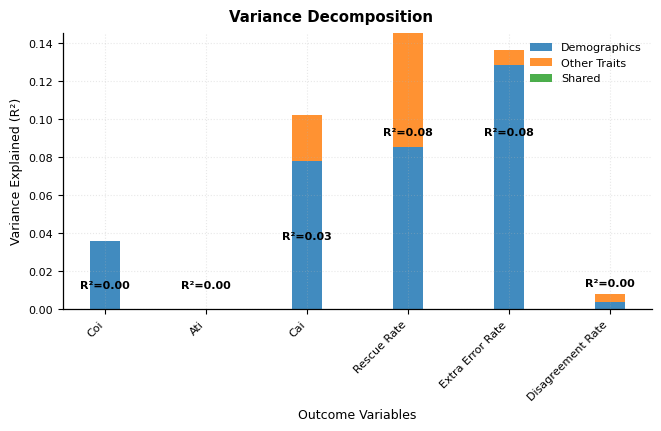

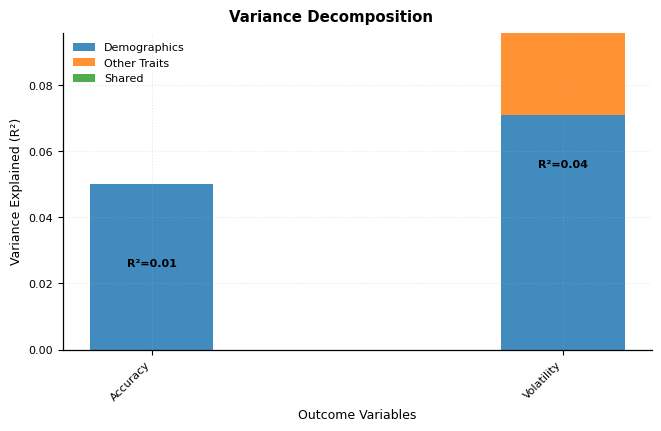

In [11]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                       case=mmlu_case,
                                       )

# Zero shot Normative


In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

### IMPORTANT: isolating the normative reasoning categories
merged_df_normative = merged_df.loc[merged_df["category"] == "normative"]

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df_normative, 
                                                    case=mmlu_case,
                                                    df=sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative, person_set=PERSON_ETHNICS, case=mmlu_case)

# Zero-shot-Control

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot.csv",
    sample_df=sample_mmlu,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

### IMPORTANT: isolating the control categories (non-normative)
merged_df_control = merged_df.loc[merged_df["category"] == "control"]

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_preliminary = run_full_preliminary_analysis(merged_df_control, 
                                                    case=mmlu_case,
                                                    df = sample_mmlu, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control, person_set=PERSON_ETHNICS, case=mmlu_case)

# Full Dataset

Augmented the data samples to verify if obtained results on **normative categories vs control categories** presented biases

## Zero Shot Full

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]
sample_mmlu_normative_full = sample_mmlu_full[sample_mmlu_full["category"] == "normative"]
results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_normative_full, person_set=PERSON_ETHNICS)

In [ ]:
sample_mmlu_full.shape
sample_mmlu_normative_full.shape

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
sample_mmlu_control_full = sample_mmlu_full[sample_mmlu_full["category"] == "control"]
results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_control_full, person_set=PERSON_ETHNICS)